# Step 1 - Timestamp Matching (new config format)

This tutorial uses the new `obs_new.ini`-style config layout.

Step 1 matches the fast-camera (PSFcam) frames to the slow-camera (PLcam) timestamps and averages the PSFcam frames that fall inside each PLcam exposure. The output is one H5 file with one matched PSFcam frame per PLcam timestamp.

## Setup

Define the paths and parameters first so the generated config file is easy to inspect and edit.

In [1]:
import os

TUTORIAL_DIR = os.path.dirname(os.path.abspath('__file__'))
# If needed, replace the line above with:
# TUTORIAL_DIR = '/absolute/path/to/PLred-dev/PLred/tutorials'

FASTCAM_DIR = os.path.join(TUTORIAL_DIR, 'data', 'fastcam')
SLOWCAM_DIR = os.path.join(TUTORIAL_DIR, 'data', 'slowcam')
FASTCAM_DARK = os.path.join(FASTCAM_DIR, 'dark.fits')

OUTPUT_DIR = os.path.join(TUTORIAL_DIR, 'tutorial_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

OBS_DATE = '20240917'
START_TIME = '15:05:10'
END_TIME = '15:05:11'

PSFCAM_IS_FAST = True
CROP_WIDTH = 20
APPLY_DEAD_TIME_CORRECTION = True

PLCAM_ROI = '0,412,1200,1220'
NFIB = 38
SPECTRAL_ORIENTATION = 'horizontal'
MAP_N = 5
MAP_WIDTH = 2
XC = 18.26
YC = 20.50
PIX2MAS = 16.2
N_BOOTSTRAP = 0
TRACE_FILE = os.path.join(OUTPUT_DIR, 'traces.npz')

print('Input fast-cam dir :', FASTCAM_DIR)
print('Input slow-cam dir :', SLOWCAM_DIR)
print('Output dir         :', OUTPUT_DIR)
print('Config file        :', os.path.join(OUTPUT_DIR, 'obs_new.ini'))

Input fast-cam dir : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam
Input slow-cam dir : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/slowcam
Output dir         : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output
Config file        : /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/obs_new.ini


## Inspect the input data

Each camera provides FITS files for the image data and `.txt` files for timestamps.

In [2]:
import glob

fc_fits = sorted(glob.glob(os.path.join(FASTCAM_DIR, '*.fits')))
fc_txt = sorted(glob.glob(os.path.join(FASTCAM_DIR, '*.txt')))
sc_txt = sorted(glob.glob(os.path.join(SLOWCAM_DIR, '*.txt')))
sc_fits = sorted(glob.glob(os.path.join(SLOWCAM_DIR, '*.fits')))

print(f'PSFcam FITS files : {len(fc_fits)}')
for f in fc_fits:
    print(f'  {os.path.basename(f)}')

print(f'\nPSFcam timestamps : {len(fc_txt)}')
for f in fc_txt:
    print(f'  {os.path.basename(f)}')

print(f'\nPLcam timestamps  : {len(sc_txt)}')
for f in sc_txt:
    print(f'  {os.path.basename(f)}')

print(f'\nPLcam FITS files  : {len(sc_fits)}  (used in Step 2, not here)')

PSFcam FITS files : 2
  cropped_palila_15:05:10.002607418.fits
  dark.fits

PSFcam timestamps : 1
  cropped_palila_15:05:10.002607418.txt

PLcam timestamps  : 1
  cropped_firstpl_15:05:17.315924371.txt

PLcam FITS files  : 2  (used in Step 2, not here)


In [3]:
import numpy as np
from astropy.io import fits

ts_data = np.loadtxt(fc_txt[0])
print('Timestamp file columns : frame_index, unix_time')
print('First 5 rows:')
print(ts_data[:5])

with fits.open(fc_fits[0]) as hdul:
    fc_shape = hdul[0].data.shape
print(f'\nPSFcam FITS shape : {fc_shape}  (n_frames, height, width)')

dark = fits.getdata(FASTCAM_DARK)
print(f'PSFcam dark shape : {dark.shape}')

Timestamp file columns : frame_index, unix_time
First 5 rows:
[[0.00000000e+00 1.55176050e+07 7.11474967e+00 1.72658552e+09
  1.72658552e+09 1.55176050e+07 0.00000000e+00]
 [1.00000000e+00 1.55176060e+07 7.12031054e+00 1.72658552e+09
  1.72658552e+09 1.55176060e+07 0.00000000e+00]
 [2.00000000e+00 1.55176070e+07 7.12550235e+00 1.72658552e+09
  1.72658552e+09 1.55176070e+07 0.00000000e+00]
 [3.00000000e+00 1.55176080e+07 7.13080049e+00 1.72658552e+09
  1.72658552e+09 1.55176080e+07 0.00000000e+00]
 [4.00000000e+00 1.55176090e+07 7.13602495e+00 1.72658552e+09
  1.72658552e+09 1.55176090e+07 0.00000000e+00]]

PSFcam FITS shape : (235, 256, 320)  (n_frames, height, width)
PSFcam dark shape : (256, 320)


## Write `obs.ini`

This is the config format we want the tutorials to use. It keeps the step inputs and step outputs in a single file.

In [ ]:
import configobj

config = configobj.ConfigObj()
config.filename = os.path.join(OUTPUT_DIR, 'obs.ini')

config['Observation'] = {
    'obsdate': OBS_DATE,
    'start_time': START_TIME,
    'end_time': END_TIME,
}
config['Fastcam'] = {
    'type': 'PSF',
    'timestamp_dir': FASTCAM_DIR + os.sep,
    'data_dir': FASTCAM_DIR + os.sep,
    'dark': FASTCAM_DARK,
}
config['Slowcam'] = {
    'type': 'PL',
    'timestamp_dir': SLOWCAM_DIR + os.sep,
    'data_dir': SLOWCAM_DIR + os.sep,
    'dark': os.path.join(SLOWCAM_DIR, 'dark.fits'),
    'slowcam_nbin': '1',
}
config['ROI'] = {
    'PLcam_ROI': PLCAM_ROI,
    'PSFcam_crop_width': str(CROP_WIDTH),
}
config['Spectrum'] = {
    'nfib': str(NFIB),
    'spectral_orientation': SPECTRAL_ORIENTATION,
}
config['ROIViewer'] = {
    'roi': PLCAM_ROI,
}
config['Average'] = {
    'map_n': str(MAP_N),
    'map_width': str(MAP_WIDTH),
    'xc': str(XC),
    'yc': str(YC),
    'pix2mas': str(PIX2MAS),
    'n_bootstrap': str(N_BOOTSTRAP),
    'time_min': 0,
    'time_max': 999999,
    'maxpix_min': 0,
    'maxpix_max': 999999,
}
config['Specextract'] = {
    'extractor': 'trace_box',
    'trace_file': TRACE_FILE,
    'truncate': '0',
}
config['Outputs'] = {
    'timestamp_match_output': os.path.join(OUTPUT_DIR, 'step1_fastcam.h5'),
    'ingest_output': os.path.join(OUTPUT_DIR, 'step2_alldata.h5'),
    'ROI_viewer_output': os.path.join(OUTPUT_DIR, 'step2_roi.h5'),
    'average_output': os.path.join(OUTPUT_DIR, 'step3_map.h5'),
    'couplingmap_output': os.path.join(OUTPUT_DIR, 'step4_couplingmap.fits'),
}
config.write()

print('Config written to:', config.filename)

Config written to: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/obs.ini


## Run timestamp matching

`script_match_timestamps` reads the new config file and writes the matched PSFcam H5 output.

number of files found: 1
total slowcam images: 49
Applied dead-time correction using frame end times


100%|██████████| 49/49 [00:00<00:00, 62677.92it/s]


PSFcam=fastcam — saving cropped frames [108:148, 140:180]
reading fastcam file /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/data/fastcam/cropped_palila_15:05:10.002607418.fits


100%|██████████| 49/49 [00:00<00:00, 2674.97it/s]

saved: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/step1_fastcam.h5  (49 frames)
timestamp matching backup saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/step1_fastcam.pkl


Diagnostics saved to /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/step1_fastcam_diagnostics.png
=== Diagnostic summary: step1_fastcam.h5 ===
fastcam frames:         235  (1 files)
slowcam matched frames: 49
Weight range: [0.0112, 1.0000]  (out-of-range: 0)
w_total: median=3.751  min=3.736  max=3.777

Step 1 complete. Output H5: /Users/yjkim/Documents/PLred2/PLred-dev/PLred/tutorials/tutorial_output/step1_fastcam.h5


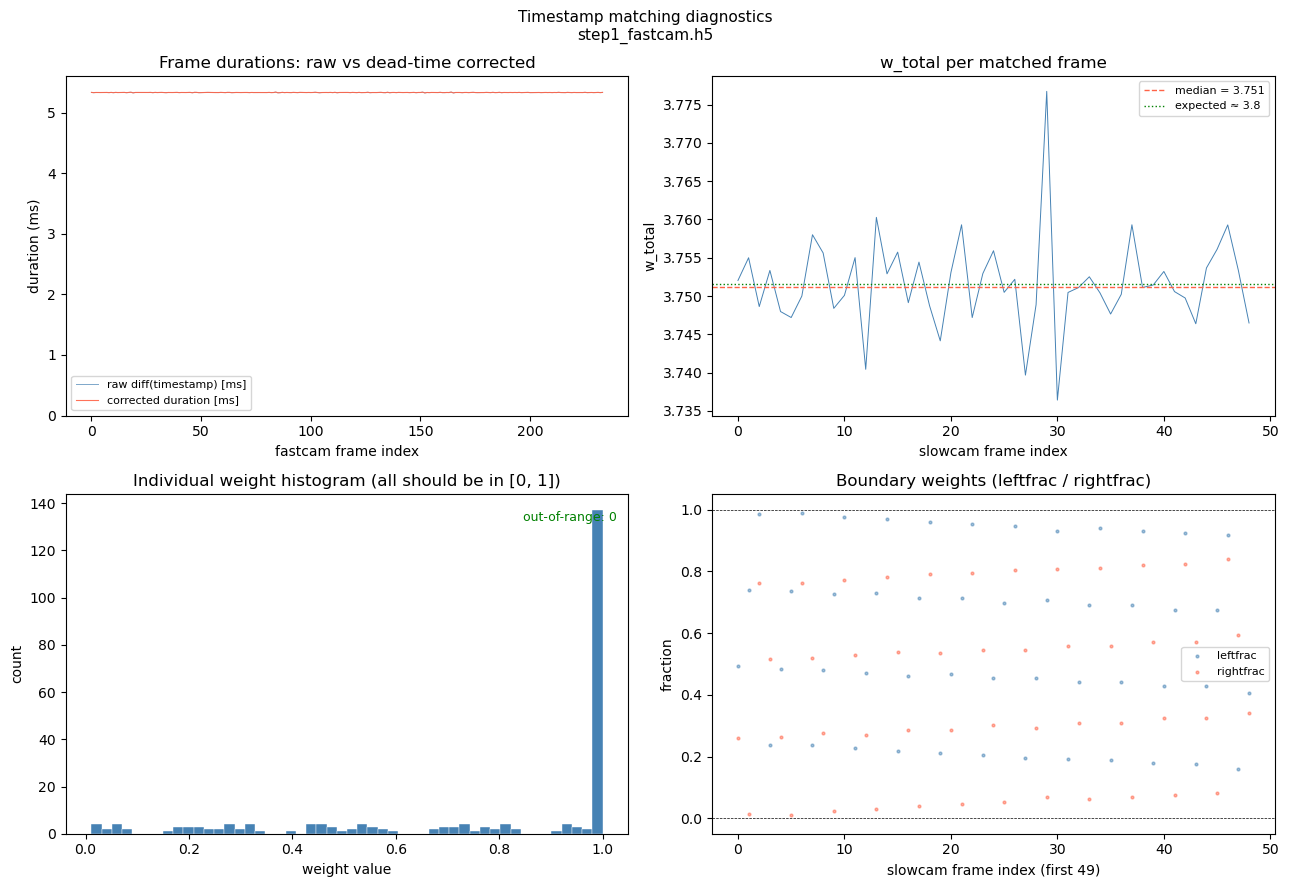

In [5]:
import sys
sys.path.insert(0, os.path.join(TUTORIAL_DIR, '..', '..'))

import PLred.sort as sort

output_h5 = sort.script_match_timestamps(config.filename)

print('\nStep 1 complete. Output H5:', output_h5)

## Inspect the output H5

The output contains one row per PLcam frame: matched PSFcam frames, stack counts, timestamps, and metadata.

In [6]:
import h5py
import json

with h5py.File(output_h5, 'r') as f:
    frames = f['frames'][:]
    nstacks = f['nstacks'][:]
    timestamps = f['timestamps'][:]
    metadata = json.loads(f['metadata'][()])

N = len(timestamps)
print(f'N matched frames   : {N}')
print(f'PSFcam frame shape : {frames.shape}  (N, height, width)')
print(f'nstacks range      : [{nstacks.min():.1f}, {nstacks.max():.1f}]')
print(f'Observation span   : {timestamps[-1] - timestamps[0]:.2f} seconds')
print(f'psfcam_is_fast     : {metadata["psfcam_is_fast"]}')

N matched frames   : 49
PSFcam frame shape : (49, 40, 40)  (N, height, width)
nstacks range      : [3.7, 3.8]
Observation span   : 0.96 seconds
psfcam_is_fast     : True


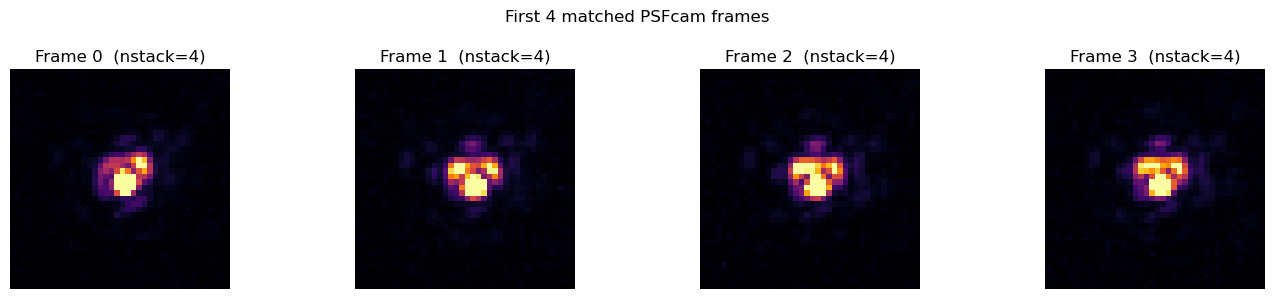

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(frames[i], origin='lower', cmap='inferno',
              vmin=np.percentile(frames[i], 5), vmax=np.percentile(frames[i], 99))
    ax.set_title(f'Frame {i}  (nstack={nstacks[i]:.0f})')
    ax.axis('off')

plt.suptitle('First 4 matched PSFcam frames')
plt.tight_layout()
plt.show()

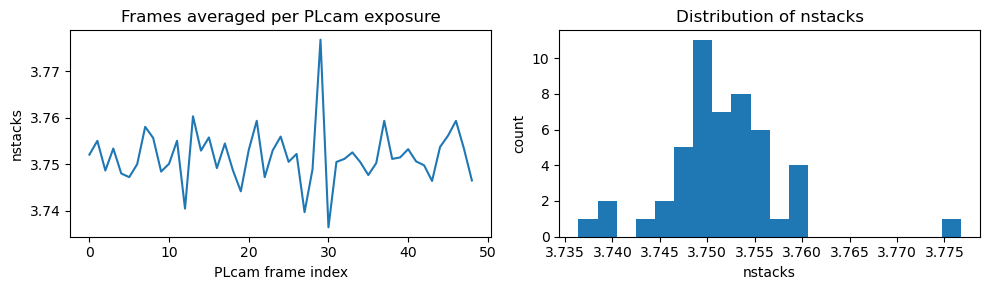

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.plot(nstacks)
ax1.set_xlabel('PLcam frame index')
ax1.set_ylabel('nstacks')
ax1.set_title('Frames averaged per PLcam exposure')

ax2.hist(nstacks, bins=20)
ax2.set_xlabel('nstacks')
ax2.set_ylabel('count')
ax2.set_title('Distribution of nstacks')

plt.tight_layout()
plt.show()

## Summary

Step 1 writes `obs_new.ini` and produces `fastcam.h5`, which contains one averaged PSFcam frame per PLcam timestamp.

Next, run the Step 2 tutorial to ingest the PLcam frames and combine them with this output.

## CLI equivalent


```bash
plred-sort /path/to/obs_new.ini
```
